In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


Bước 1: đọc file đưa vào dataframe

In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier



from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score

import datetime
import xgboost as xgb


import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE BAN ĐẦU CHƯA CHUẨN HÓA
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.6.TaoNhanMoi/Lung_Cancer_Risk_3Levels.csv')

#in dữ liệu sau khi đọc từ file
print(df)

      AGE_RISK  SMOKING_RISK  FAMILY_HISTORY_RISK  CHRONIC_DISEASE_RISK  \
0            1             1                    0                     0   
1            1             1                    0                     0   
2            0             1                    0                     1   
3            1             1                    0                     1   
4            0             0                    0                     1   
...        ...           ...                  ...                   ...   
2958         1             0                    1                     1   
2959         0             1                    0                     0   
2960         0             0                    0                     0   
2961         1             0                    0                     0   
2962         0             1                    0                     1   

      LOW_OXYGEN_RISK  EXPOSURE_RISK  SYMPTOM_RISK  RISK_SCORE RISK_LEVEL  
0                   0  

Code chuẩn hóa bộ dữ liệu

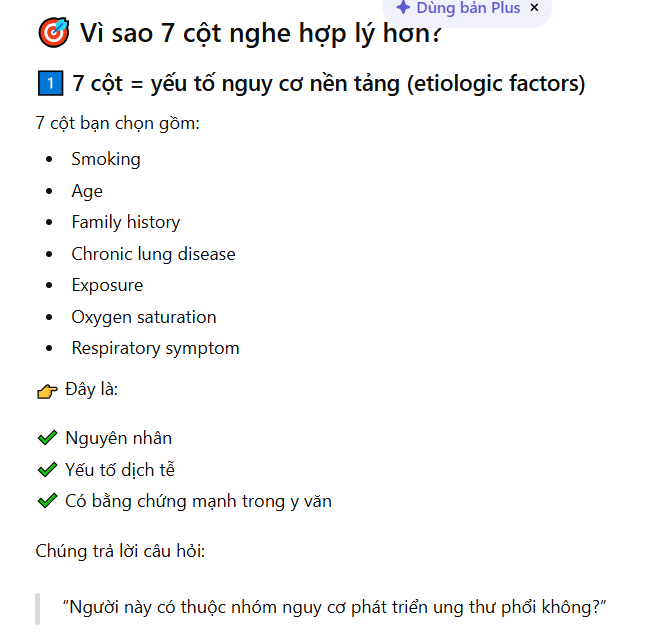

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# =====================================================
# 1️⃣ LOAD DATA
# =====================================================


print("Shape ban đầu:", df.shape)

# =====================================================
# 2️⃣ XÓA CỘT TRỐNG / UNNAMED
# =====================================================
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^unnamed', case=False)]

# =====================================================
# 3️⃣ CHUẨN HÓA TÊN CỘT
# =====================================================
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# =====================================================
# 4️⃣ KIỂM TRA MISSING VALUE
# =====================================================
print("\nMissing values:")
print(df.isna().sum())

# Nếu có missing numeric → fill median
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# =====================================================
# 5️⃣ ENCODE CÁC CỘT YES/NO
# =====================================================
binary_cols = []

for col in df.columns:
    if df[col].nunique() == 2:
        if df[col].dtype == 'object':
            binary_cols.append(col)

for col in binary_cols:
    df[col] = df[col].map({'YES':1, 'NO':0, 'Yes':1, 'No':0})

# =====================================================
# 6️⃣ ENCODE NHÃN 3 MỨC RISK
# =====================================================
if 'risk_level' in df.columns:
    le = LabelEncoder()
    df['risk_level'] = le.fit_transform(df['risk_level'])

    print("\nMapping Risk Level:")
    print(dict(zip(le.classes_, range(len(le.classes_)))))

# =====================================================
# 7️⃣ SCALE NUMERIC FEATURES
# (KHÔNG scale cột nhãn)
# =====================================================
features = df.drop(columns=['risk_level'])
target = df['risk_level']

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

X = pd.DataFrame(features_scaled, columns=features.columns)
y = target

# =====================================================
# 8️⃣ GHÉP LẠI DATASET CHUẨN HÓA
# =====================================================
df_normalized = pd.concat([X, y], axis=1)

print("\nShape sau chuẩn hóa:", df_normalized.shape)

# =====================================================
# 9️⃣ LƯU FILE CHUẨN HÓA
# =====================================================
output_path = "/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.6.TaoNhanMoi/Lung_Cancer_Risk_3Levels_Normalized.csv"
df_normalized.to_csv(output_path, index=False)

print("\n✅ HOÀN TẤT CHUẨN HÓA")
print("File đã lưu:", output_path)

# =====================================================
# 🔟 KIỂM TRA KẾT QUẢ
# =====================================================
print("\nKiểm tra thống kê:")
print(df_normalized.describe().T)

Shape ban đầu: (2963, 9)

Missing values:
age_risk                0
smoking_risk            0
family_history_risk     0
chronic_disease_risk    0
low_oxygen_risk         0
exposure_risk           0
symptom_risk            0
risk_score              0
risk_level              0
dtype: int64

Mapping Risk Level:
{'High': 0, 'Low': 1, 'Moderate': 2}

Shape sau chuẩn hóa: (2963, 9)

✅ HOÀN TẤT CHUẨN HÓA
File đã lưu: /content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.6.TaoNhanMoi/Lung_Cancer_Risk_3Levels_Normalized.csv

Kiểm tra thống kê:
                       count          mean       std       min       25%  \
age_risk              2963.0 -1.678636e-17  1.000169 -1.074667 -1.074667   
smoking_risk          2963.0  9.592207e-18  1.000169 -0.972369 -0.972369   
family_history_risk   2963.0 -3.956785e-17  1.000169 -0.588393 -0.588393   
chronic_disease_risk  2963.0  4.196591e-17  1.000169 -0.875697 -0.875697   
low_oxygen_risk       2963.0 -5.275714e-17  1.000169 -0.598271 -0.5982